# The return period of extreme precipitation

In this tutorial, we'll explore what a return period is and how we can use it to define **extreme precipitation**. We will use historical climate model outputs to calculate the thresholds of daily precipitation associated with return periods of, e.g., 10-, 20-, and 50-years. To do so, we will use preprocessed climate model outputs for the Molise region in Italy (NUTS2 region ITF2). 

```{admonition} Learning Objectives
:class: tip
By the end of this tutorial, you will understand:
- What a return period is and how it can be used to define extreme precipitation events
- How to estimate return periods from a timeseries of daily precipitation
- Sources of uncertainty embedded in the calculation of return periods
```

```{admonition} Prerequisites
:class: note
This tutorial uses preprocessed CSV data for the Molise region in Italy (ITF2). See the [How-To Guide on Projections of Precipitation](../how-to-guides/precipitation_c3satlas.ipynb) to download and process precipitation projections from the CDS. 
```

## Settings

### Modules used

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path
from scipy.stats import genextreme

# Configure plotting
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

### User settings

In [22]:
# Configuration
admin_id = 'ITF2'

# Reference period for baseline statistics
baseline_start = 1976
baseline_end = 2005

# Analysis settings
rolling_window = 30  # years for rolling mean

# Paths
workdir = Path("/home/nejk/code/extreme_precip_exposure")
os.chdir(workdir)
data_dir = workdir / 'data' / admin_id / 'extreme_precip_exposure'

# Load preprocessed data
print(f"Region: {admin_id} (Molise, Italy)")
test_file = data_dir / f'{admin_id}_precip_hist_all_points_member0.csv'
print(f"Test data: {test_file}")
hist_file = data_dir / f'{admin_id}_precip_hist_amax_nutsmax.csv'
print(f"Historical data: {hist_file}")
proj_file = data_dir / f'{admin_id}_precip_proj_amax_nutsmax.csv'
print(f"Projection data: {proj_file}")

Region: ITF2 (Molise, Italy)
Test data: /home/nejk/code/extreme_precip_exposure/data/ITF2/extreme_precip_exposure/ITF2_precip_hist_all_points_member0.csv
Historical data: /home/nejk/code/extreme_precip_exposure/data/ITF2/extreme_precip_exposure/ITF2_precip_hist_amax_nutsmax.csv
Projection data: /home/nejk/code/extreme_precip_exposure/data/ITF2/extreme_precip_exposure/ITF2_precip_proj_amax_nutsmax.csv


### Data used

For this tutorial, we'll use preprocessed data, which we downloaded and preprocessed for the Molise region (Italy) in the 
- [how-to guide on processing precipitation from climate model outputs](../how-to-guides/precipitation_c3satlas.ipynb). 

In this how-to-guide, we downloaded the CORDEX-EUR11 ensemble from the [Gridded datasets underpinning the Copernicus Interactive Climate Atlas](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview) and more specifically, the variable **monthly maximum 1-day precipitation**. 

The data that we load here represents either one (random) model but all points in the region and timesteps available, loaded as `test_file`, or all models but only the annual and regional maximumm (stored in `hist_file` and `proj_file` for the historical and future periods, respectively). 

## Return periods explained

#### Example timeseries of monthly maximum of daily precipitation

We'll use the outputs from one (random) model here to illustrate a timeseries of monthly maximum of daily precipitation.

In [23]:
# Read test_file and plot timeseries of monthly maximum precipitation for one random point in the region
test_df = pd.read_csv(test_file, parse_dates=['time'])
test_df.head()
print(f"The test data contains {len(test_df)} rows and covers the period from {test_df['time'].min().date()} to {test_df['time'].max().date()}. ")
print(f"\nThe underlying climate model is entitled {test_df['member_id'].unique()[0]}.")
print(f"The naming indicates the global and regional climate model (GCM and RCM, respectively) institutions, models, and variants:")
print(f" - GCM institution: {test_df['gcm_institution'].unique()[0]}")
print(f" - GCM model: {test_df['gcm_model'].unique()[0]}")
print(f" - GCM variant: {test_df['gcm_variant'].unique()[0]}")
print(f" - RCM institution: {test_df['rcm_institution'].unique()[0]}")
print(f" - RCM model: {test_df['rcm_model'].unique()[0]}")
print(f" - RCM variant: {test_df['rcm_variant'].unique()[0]}")

The test data contains 38880 rows and covers the period from 1970-01-01 to 2005-12-01. 

The underlying climate model is entitled CCCma_CanESM2_r1i1p1_CLMcom_CCLM4-8-17_v1.
The naming indicates the global and regional climate model (GCM and RCM, respectively) institutions, models, and variants:
 - GCM institution: CCCma
 - GCM model: CanESM2
 - GCM variant: r1i1p1
 - RCM institution: CLMcom
 - RCM model: CCLM4-8-17
 - RCM variant: v1


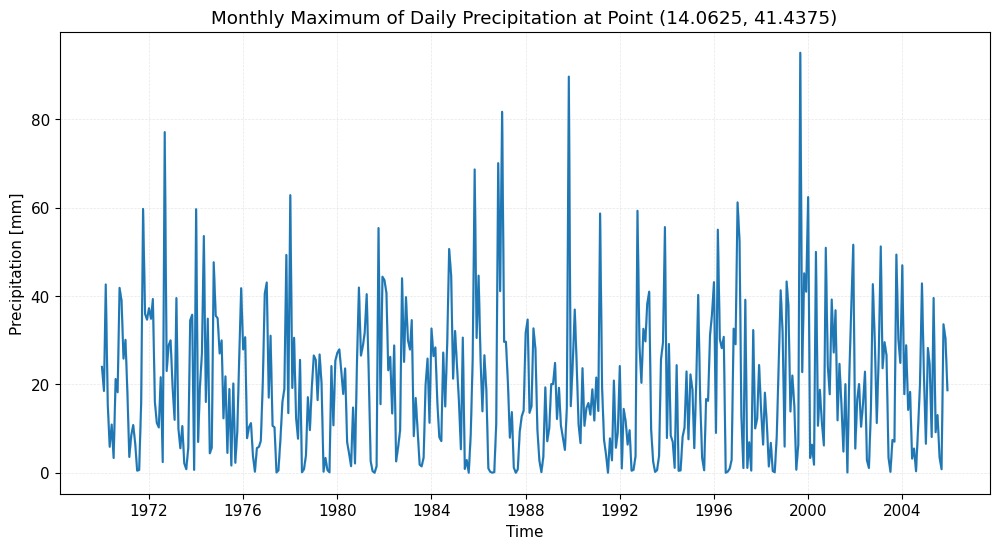

In [24]:
# Select one random point (e.g., the first lon/lat combination) and plot the timeseries of monthly maximum precipitation
point_df = test_df[(test_df['lon'] == test_df['lon'].unique()[0]) & (test_df['lat'] == test_df['lat'].unique()[0])]
plt.figure(figsize=(12, 6))
sns.lineplot(data=point_df, x='time', y='rx1day')
plt.title(f'Monthly Maximum of Daily Precipitation at Point ({point_df["lon"].iloc[0]}, {point_df["lat"].iloc[0]})')
plt.xlabel('Time')
plt.ylabel('Precipitation [mm]')
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

Through the selection of the **monthly maximum of daily precipitation**, we have already performed a first screening for extremes at the daily scale. However, we can also perform a second screening and look at annual maxima.

### Using annual maxima to define extreme events

Using this data, we can, for example, understand during which month the most intense daily precipitation falls or identify months during which precipitation extremes are rare. 

In [44]:
point_df = point_df.copy()
point_df.loc[:, 'month'] = point_df['time'].dt.month
point_df.loc[:, 'year'] = point_df['time'].dt.year

# Print statistics for this point, indicating months with highest and lowest precipitation, and the overall mean and standard deviation
mean_precip = point_df['rx1day'].mean()
std_precip = point_df['rx1day'].std()
max_precip = point_df['rx1day'].max()
min_precip = point_df['rx1day'].min()
max_month = point_df.loc[point_df['rx1day'].idxmax(), 'month']
min_month = point_df.loc[point_df['rx1day'].idxmin(), 'month']
print(f"Statistics for point ({point_df['lon'].iloc[0]}, {point_df['lat'].iloc[0]}):")
print(f" - Mean monthly maximum daily precipitation: {mean_precip:.2f} mm")
print(f" - Standard deviation: {std_precip:.2f} mm")
print(f" - Maximum monthly maximum daily precipitation: {max_precip:.2f} mm (in month {max_month})")
print(f" - Minimum monthly maximum daily precipitation: {min_precip:.2f} mm (in month {min_month})")

Statistics for point (14.0625, 41.4375):
 - Mean monthly maximum daily precipitation: 19.64 mm
 - Standard deviation: 16.34 mm
 - Maximum monthly maximum daily precipitation: 95.02 mm (in month 9)
 - Minimum monthly maximum daily precipitation: 0.00 mm (in month 8)


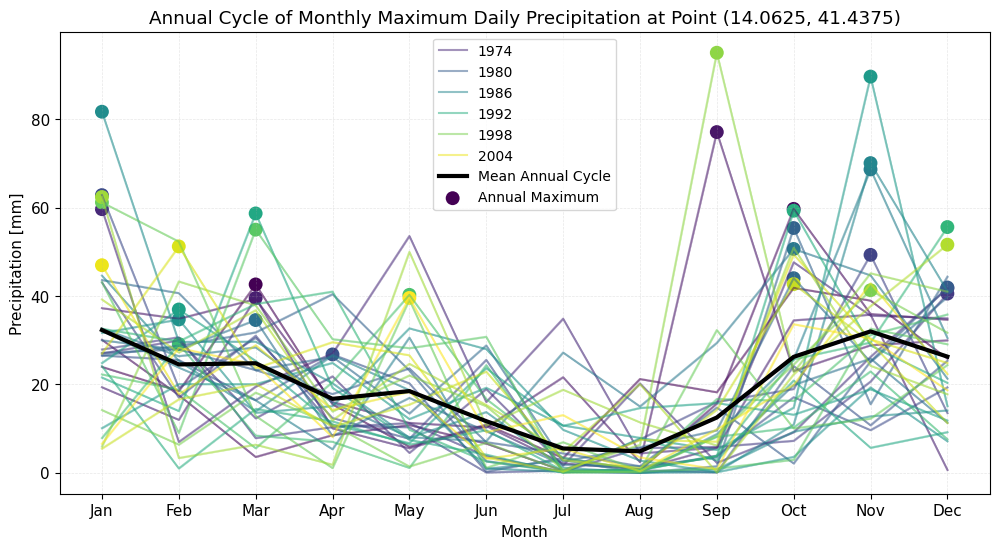

In [43]:
# Annual cycle plot, highlight the annual maximum per year using a colored dot in the same color as the year lines
plt.figure(figsize=(12, 6))
sns.lineplot(data=point_df, x='month', y='rx1day', hue='year', palette='viridis', legend=True, alpha=0.5)
sns.lineplot(data=point_df.groupby('month')['rx1day'].mean().reset_index(), x='month', y='rx1day', color='black', label='Mean Annual Cycle', linewidth=3)
annual_max_df = point_df.groupby('year').apply(lambda x: x.loc[x['rx1day'].idxmax()], include_groups=False).reset_index()
sns.scatterplot(data=annual_max_df, x='month', y='rx1day', hue='year', palette='viridis', legend=False, s=100, edgecolor='None', label='Annual Maximum')
plt.title(f'Annual Cycle of Monthly Maximum Daily Precipitation at Point ({point_df["lon"].iloc[0]}, {point_df["lat"].iloc[0]})')
plt.xlabel('Month')
# convert x-axis ticks to month names
plt.xticks(ticks=np.arange(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Precipitation [mm]')
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.legend(loc='upper center', fontsize=10, frameon=True) 

_**Can you spot the annual maxima for each year in this plot?**_

No single year captures all deviations from the mean — that's why we need a long climatology to define an extreme event. The World Meteorological Organisation suggests to use (at least) 30 years of data to do so! 

In [28]:
# print months with most and least annual maximum precipitation
annual_max_idx = point_df.groupby('year')['rx1day'].idxmax()
annual_max_months = point_df.loc[annual_max_idx].set_index('year')['month']
most_common_max_month = annual_max_months.mode().iloc[0]
# account for months without any annual maximum precipitation (i.e., if a month has no annual maximum precipitation, it should be counted and listed as least common month!)
all_months = pd.Series(np.arange(1, 13))
least_common_max_month = all_months[~all_months.isin(annual_max_months)].tolist()
if not least_common_max_month:
    least_common_max_month = annual_max_months.value_counts().idxmin()

print(f"The most common month for the annual maximum precipitation is month {most_common_max_month} with {annual_max_months.value_counts().max()} occurrences.")  
print(f"The least common month for the annual maximum precipitation are months {least_common_max_month}.")

The most common month for the annual maximum precipitation is month 1 with 6 occurrences.
The least common month for the annual maximum precipitation are months [6, 7, 8].


### A statistical model for the occurrence of extremes

The annual maxima help us to further refine what we call an extreme precipitation event — and they are the basis for the definition of **return periods**, which are expressed in units of years. 

So, let's look at these annual maxima a bit more closely, and let's plot them on a histogram to understand their occurrence. To model the behavior of the annual maxima of daily precipitation at this grid point, we also fit a **Generalised Extreme Value** distribution to the histogram.  

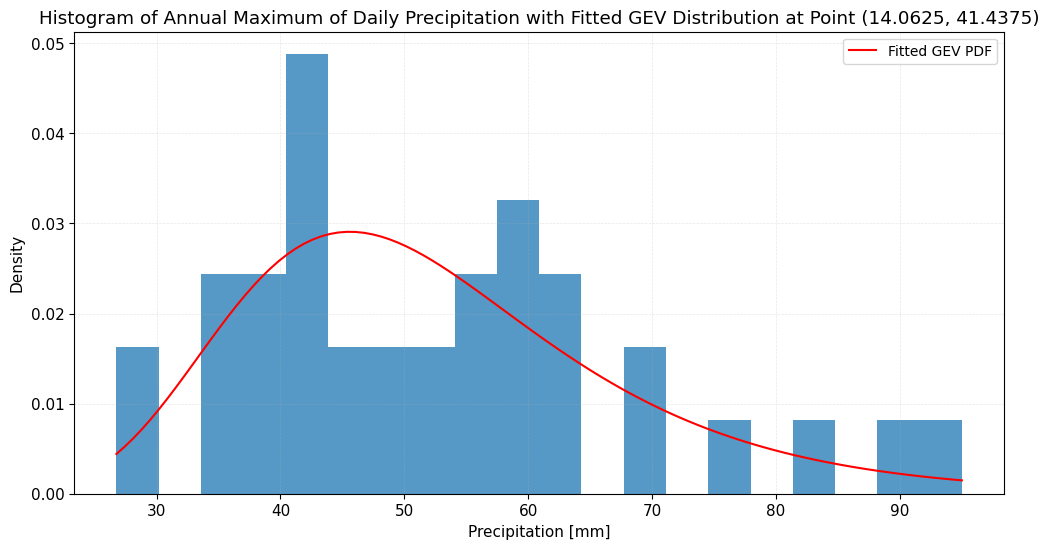

In [29]:
# Fit a GEV distribution to the annual maxima and plot it on top of the above histogram
gev_params = genextreme.fit(annual_max_df['rx1day'])
x = np.linspace(annual_max_df['rx1day'].min(), annual_max_df['rx1day'].max(), 100)
pdf = genextreme.pdf(x, *gev_params)
plt.figure(figsize=(12, 6))
sns.histplot(annual_max_df['rx1day'], bins=20, edgecolor='None', stat='density')
plt.plot(x, pdf, color='red', label='Fitted GEV PDF')
plt.title(f'Histogram of Annual Maximum of Daily Precipitation with Fitted GEV Distribution at Point ({point_df["lon"].iloc[0]}, {point_df["lat"].iloc[0]})')
plt.xlabel('Precipitation [mm]')
plt.ylabel('Density')
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', fontsize=10, frameon=True)    

### Definition of return periods

The above histogram and fitted GEV distribution already indicate probability of an event to occur, e.g., an event larger than 80 mm per day (intensity), occurring. The return period is defined using this **exceedance probability**. 


```{admonition} What is a return period?
:class: note
 A return period (or recurrence interval) is a statistical measurement that denotes the average time between two extreme events of the same intensity. The return period is calculated as the inverse of the exceedance probability that such an event will occur in a given year. For example, an event with a 100-year return period has a 1% chance of occuring in any single year (rather than a guaranteed once-a-century occurrence).
```

Using the fitted GEV, we can use its probability density function (PDF) and cumulative density function (CDF) to estimate the probability of exceedance for specific thresholds. The vertical red dashed lines indicate such exceedance probabilities and the corresponding return period. 

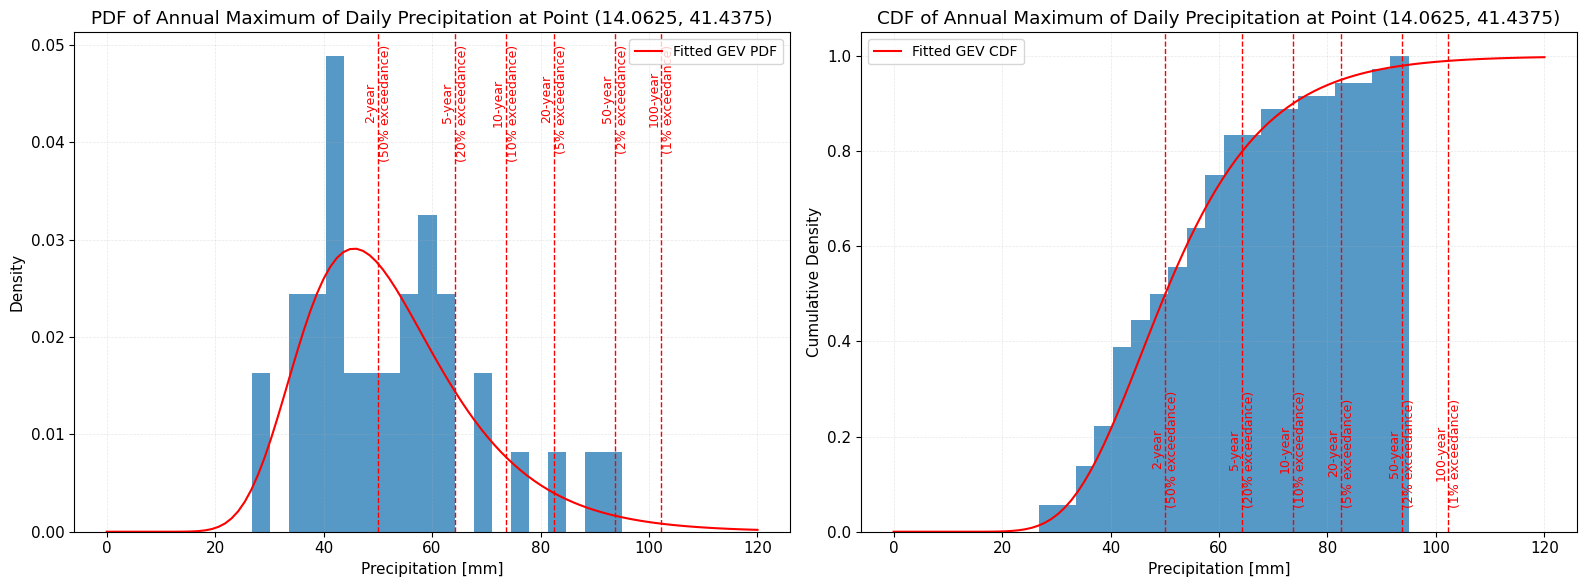

In [30]:
# Repeat the two-panel plot above but introduce vertical lines indicating the return levels for return periods of 2, 5, 10, 20, 50, and 100 years
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# PDF
sns.histplot(annual_max_df['rx1day'], bins=20, edgecolor='None', stat='density', ax=axes[0])
x = np.linspace(0, annual_max_df['rx1day'].max()+25, 100)
pdf = genextreme.pdf(x, *gev_params)
axes[0].plot(x, pdf, color='red', label='Fitted GEV PDF')
axes[0].set_title(f'PDF of Annual Maximum of Daily Precipitation at Point ({point_df["lon"].iloc[0]}, {point_df["lat"].iloc[0]})')
axes[0].set_xlabel('Precipitation [mm]')
axes[0].set_ylabel('Density')
axes[0].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[0].legend(loc='upper left', fontsize=10, frameon=True)
# CDF
sns.histplot(annual_max_df['rx1day'], bins=20, edgecolor='None', stat='density', cumulative=True, ax=axes[1])
cdf = genextreme.cdf(x, *gev_params)
axes[1].plot(x, cdf, color='red', label='Fitted GEV CDF')
axes[1].set_title(f'CDF of Annual Maximum of Daily Precipitation at Point ({point_df["lon"].iloc[0]}, {point_df["lat"].iloc[0]})')
axes[1].set_xlabel('Precipitation [mm]')
axes[1].set_ylabel('Cumulative Density')
axes[1].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[1].legend(loc='upper left', fontsize=10, frameon=True)
# Add vertical lines for return levels
return_periods = np.array([2, 5, 10, 20, 50, 100])
return_levels = genextreme.ppf(1 - 1/return_periods, *gev_params)
for rp, rl in zip(return_periods, return_levels):
    axes[0].axvline(rl, color='red', linestyle='--', linewidth=1, label=None)
    axes[1].axvline(rl, color='red', linestyle='--', linewidth=1, label=None)
# annotate the vertical lines and write exceedance probability vertically along the dashed lines in the PDF panel, and return level in the CDF panel
for rp, rl in zip(return_periods, return_levels):
    axes[0].annotate(f'{rp}-year\n({1/rp:.0%} exceedance)', xy=(rl, 0), xytext=(rl, 0.05), textcoords='data', ha='center', va='top', fontsize=9, color='red', rotation=90)
    axes[1].annotate(f'{rp}-year\n({1/rp:.0%} exceedance)', xy=(rl, 0), xytext=(rl, 0.05), textcoords='data', ha='center', va='bottom', fontsize=9, color='red', rotation=90)
axes[0].legend(loc='upper right', fontsize=10, frameon=True)
axes[1].legend(loc='upper left', fontsize=10, frameon=True)
plt.tight_layout()  

### Return level plot

To establish a clear relationship between the return period and the associated annual precipitation intensity (or return level), we can also plot these against each other.

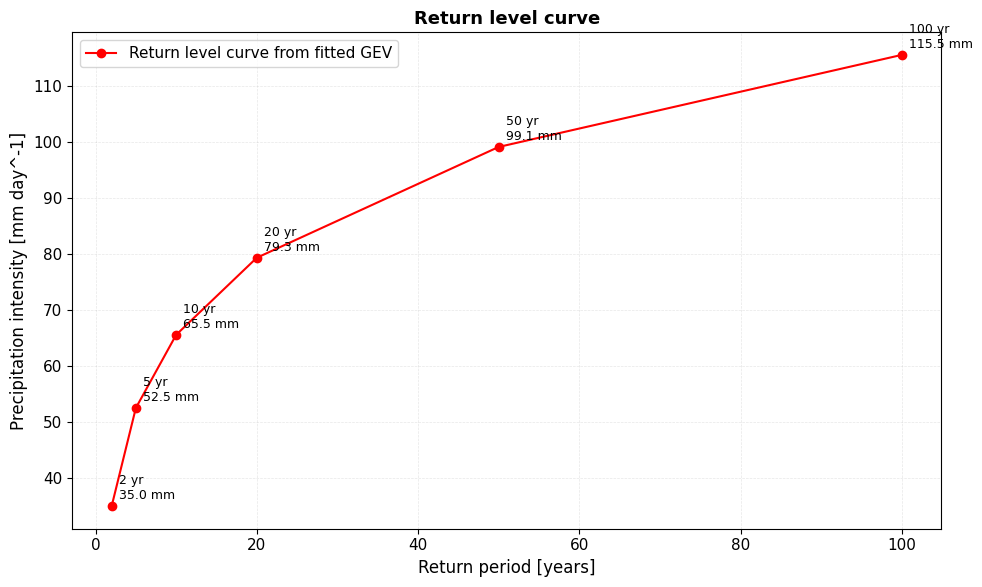

In [67]:
return_periods = np.array([2, 5, 10, 20, 50, 100])

# plot the return level curve for return periods from 2 to 100 years
return_levels = genextreme.ppf(1 - 1/return_periods, *gev_params)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(return_periods, return_levels, marker='o', color='red', label='Return level curve from fitted GEV')
#ax.set_xscale('log')
ax.set_xlabel('Return period [years]', fontsize=12)
ax.set_ylabel('Precipitation intensity [mm day^-1]', fontsize=12)
ax.set_title(f'Return level curve', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# annotate all points with the return period and return level
for rp, rl in zip(return_periods, return_levels):
    ax.annotate(f'{rp} yr\n{rl:.1f} mm', xy=(rp, rl), xytext=(5, 5), textcoords='offset points', fontsize=9)
# add vertical line at length of years in dataset used for fitting
ax.legend(loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()   

In [47]:
# Print thresholds associated with return periods of 2, 5, 10, 20, 50, and 100 years
print("Precipitation intensity associated with different return periods at the selected point:")
for rp, rl in zip(return_periods, return_levels):
    print(f" - {rp}-year return period: {rl:.2f} mm year^-1")   

Precipitation intensity associated with different return periods at the selected point:
 - 2-year return period: 50.10 mm year^-1
 - 5-year return period: 64.30 mm year^-1
 - 10-year return period: 73.61 mm year^-1
 - 20-year return period: 82.46 mm year^-1
 - 50-year return period: 93.83 mm year^-1
 - 100-year return period: 102.27 mm year^-1


## Uncertainties embedded in the estimation of return periods

From the plots above, we can already define one uncertainty associated with the definition of return periods: the goodness of the fit. 

However, there are also a few other uncertainties going into the estimation of the return period, that we briefly illustrate here. 

### Baseline period uncertainty

In the plots above, we used all data available for the historical model climate simulations. 

In [52]:
print(f"The data used for fitting the GEV distribution covers {len(point_df['time'].dt.year.unique())} years and the period from {point_df['time'].min().date()} to {point_df['time'].max().date()}.")

The data used for fitting the GEV distribution covers 36 years and the period from 1970-01-01 to 2005-12-01.


The World Meteorological Organisation suggests using (at least) 30 years of data. So, let's quickly assess the difference of using 30 years against the full time period. 


Calculating return level curves for the baseline period (1976-2005) and comparing to the return level curve from the full data period.


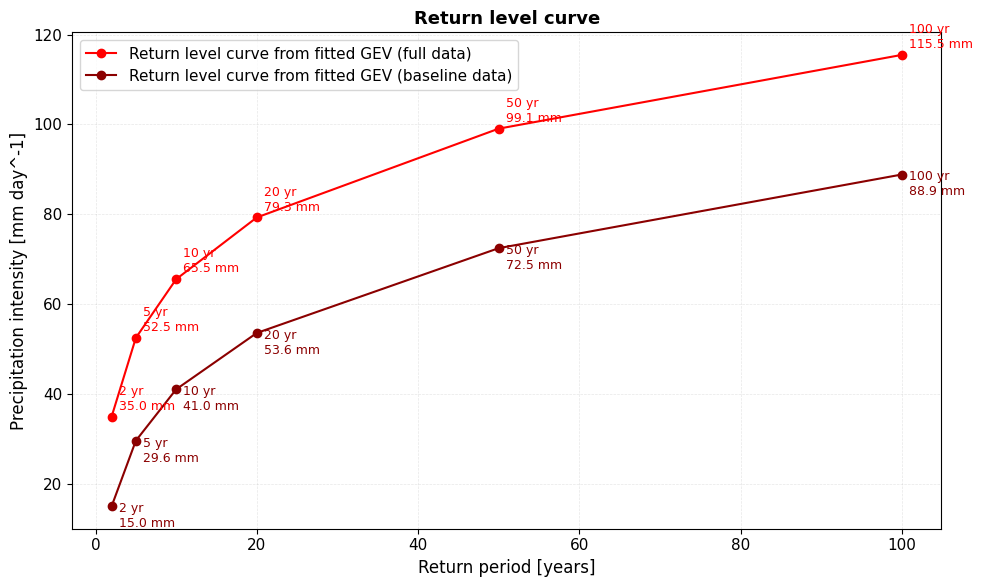

In [92]:
# Extract data for baseline period defined in the settings above
print(f"\nCalculating return level curves for the baseline period ({baseline_start}-{baseline_end}) and comparing to the return level curve from the full data period.")
point_df_baseline = point_df[(point_df['year'] >= baseline_start) & (point_df['year'] <= baseline_end)]
gev_params_baseline = genextreme.fit(point_df_baseline['rx1day'])
return_levels_baseline = genextreme.ppf(1 - 1/return_periods, *gev_params_baseline)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(return_periods, return_levels, marker='o', color='red', label='Return level curve from fitted GEV (full data)')
ax.plot(return_periods, return_levels_baseline, marker='o', color='darkred', linestyle='-', label='Return level curve from fitted GEV (baseline data)')
ax.set_xlabel('Return period [years]', fontsize=12)
ax.set_ylabel('Precipitation intensity [mm day^-1]', fontsize=12)
ax.set_title(f'Return level curve', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# annotate all points with the return period and return level
for rp, rl in zip(return_periods, return_levels):
    ax.annotate(f'{rp} yr\n{rl:.1f} mm', xy=(rp, rl), xytext=(5, 5), textcoords='offset points', fontsize=9, color='red')
for rp, rl in zip(return_periods, return_levels_baseline):
    ax.annotate(f'{rp} yr\n{rl:.1f} mm', xy=(rp, rl), xytext=(5, -15), textcoords='offset points', fontsize=9, color='darkred')
plt.tight_layout()

Since fewer extremes are represented, the GEV based on a shorter time period is usually defining the return periods based on lower precipitation intensities. 

### Spatial uncertainty

Another uncertainty embedded in the estimation of the return periods is the spatial uncertainty. Climate models cannot resolve extremes at the exact location; so let's use the extremes in a specific region (here NUTS2 region Molise, Italy) to illustrate how much the return level curve can vary across the region and how representative the single point is for the region as a whole.

Number of unique points in the region: 45


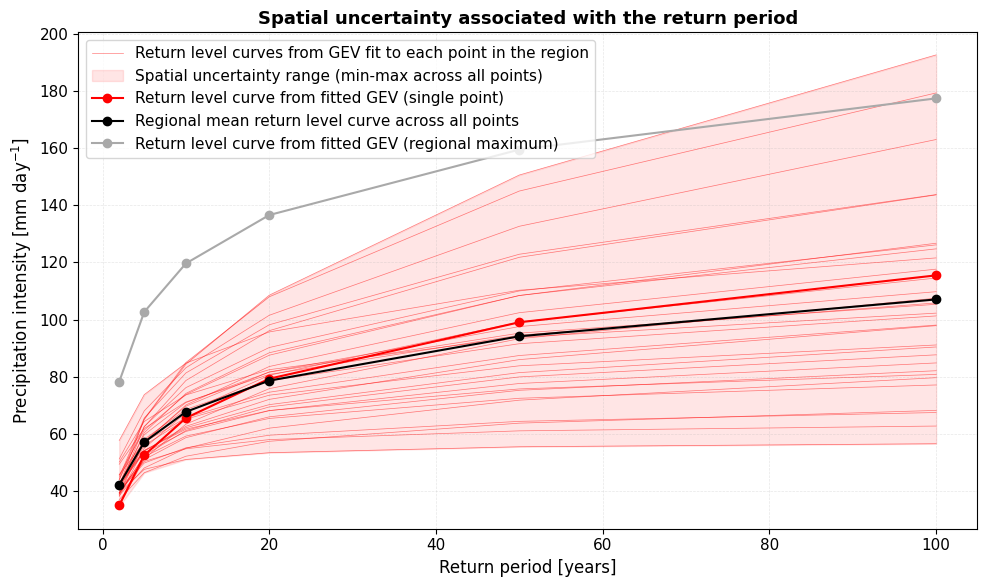

In [91]:
# Use again the full data period but now plot the return level curve for all points in the region (i.e., for all lon/lat combinations) and compare to the return level curve from the single point used above. 
test_df['point_id'] = test_df['lon'].astype(str) + '_' + test_df['lat'].astype(str)
print(f"Number of unique points in the region: {test_df['point_id'].nunique()}")
test_df['year'] = test_df['time'].dt.year

return_periods = np.array([2, 5, 10, 20, 50, 100])
return_levels_all_points = []
for point_id, group in test_df.groupby('point_id'):
    annual_max_per_point = group.groupby('year')['rx1day'].max().dropna()
    if len(annual_max_per_point) < 5:
        continue
    gev_params = genextreme.fit(annual_max_per_point)
    return_levels_point = genextreme.ppf(1 - 1/return_periods, *gev_params)
    return_levels_all_points.append(return_levels_point)
return_levels_all_points = np.array(return_levels_all_points)
# plot
fig, ax = plt.subplots(figsize=(10, 6))
# plot return level curves for all points in the region
for i in range(return_levels_all_points.shape[0]):
    ax.plot(return_periods, return_levels_all_points[i, :], color='red', alpha=0.5, linewidth=0.5, label="Return level curves from GEV fit to each point in the region" if i == 0 else None)
# add shading for the range of return levels across all points
ax.fill_between(return_periods, return_levels_all_points.min(axis=0), return_levels_all_points.max(axis=0), color='red', alpha=0.1, label='Spatial uncertainty range (min-max across all points)')
# plot return level curve for the single point used before above
ax.plot(return_periods, return_levels, marker='o', color='red', label='Return level curve from fitted GEV (single point)')
# plot regional mean return level curve across all points
regional_mean_return_levels = return_levels_all_points.mean(axis=0)
ax.plot(return_periods, regional_mean_return_levels, marker='o', color='black', linestyle='-', label='Regional mean return level curve across all points')
# extract regional maximum of the annual maximum from all points and fit a GEV distribution to it and plot the return level curve for the regional maximum
regional_max_annual_max = test_df.groupby(['year', 'point_id'])['rx1day'].max().groupby('year').max()
gev_params_regional_max = genextreme.fit(regional_max_annual_max)
return_levels_regional_max = genextreme.ppf(1 - 1/return_periods, *gev_params_regional_max)
ax.plot(return_periods, return_levels_regional_max, marker='o', color='darkgrey', linestyle='-', label='Return level curve from fitted GEV (regional maximum)')
ax.set_xlabel('Return period [years]', fontsize=12)
ax.set_ylabel('Precipitation intensity [mm day$^{-1}$]', fontsize=12)
ax.set_title(f'Spatial uncertainty associated with the return period', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()


In [89]:
print("Range of precipitation intensities across all points in the region for different return periods:")
for i, rp in enumerate(return_periods):
    print(f" - {rp}-year return period: {return_levels_all_points[:, i].min():.2f} to {return_levels_all_points[:, i].max():.2f} mm per day")

Range of precipitation intensities across all points in the region for different return periods:
 - 2-year return period: 34.66 to 57.66 mm per day
 - 5-year return period: 46.36 to 73.71 mm per day
 - 10-year return period: 51.02 to 84.96 mm per day
 - 20-year return period: 53.38 to 108.56 mm per day
 - 50-year return period: 55.46 to 150.64 mm per day
 - 100-year return period: 56.53 to 192.71 mm per day


### Model uncertainty

So far, we have only used one climate model - but the power lies in using multiple models! So, let's estimate the sensitivity of the return period to the climate model employed. 

In [106]:
# Use hist_df and fit a GEV distribution to each member_id and plot the return level curve for each member_id to show the uncertainty across different climate model runs (i.e., different GCM-RCM combinations).
unique_members = hist_df['member_id'].unique()
#for member in unique_members:
    #member_df = hist_df[hist_df['member_id'] == member]
    #annual_max_per_member = member_df.groupby('year')['rx1day'].max().dropna()
    #if len(annual_max_per_member) < 5:
    #    continue
    #gev_params_member = genextreme.fit(annual_max_per_member)
    #return_levels_member = genextreme.ppf(1 - 1/return_periods, *gev_params_member)
    #plt.plot(return_periods, return_levels_member, marker='o', label=f'Return level curve for member {member}')
#plt.xlabel('Return period [years]', fontsize=12)
#plt.ylabel('Precipitation intensity [mm day$^{-1}$]', fontsize=12)
#plt.title(f'Uncertainty in return level curves across different climate model runs', fontsize=13, fontweight='bold')
#plt.legend(loc='upper left', fontsize=10, frameon=True)
#plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
#plt.tight_layout()  

 # use plotly to plot the return level curve for each member_id and remove the legend for each member_id to avoid overcrowding the legend, and add a single legend entry for all member_ids
import plotly.graph_objects as go
fig = go.Figure()
for member in unique_members:
    member_df = hist_df[hist_df['member_id'] == member]
    annual_max_per_member = member_df.groupby('year')['rx1day'].max().dropna()
    if len(annual_max_per_member) < 5:
        continue
    gev_params_member = genextreme.fit(annual_max_per_member)
    return_levels_member = genextreme.ppf(1 - 1/return_periods, *gev_params_member)
    fig.add_trace(go.Scatter(x=return_periods, y=return_levels_member, mode='lines+markers', name=f'{member}', line=dict(width=1), marker=dict(size=6)))
fig.update_layout(title='Uncertainty in return level curves across the multi-model ensemble', 
                  xaxis_title='Return period [years]', 
                  yaxis_title='Precipitation intensity [mm day<sup>-1</sup>]', 
                  legend_title='Ensemble member', legend=dict(font=dict(size=10), bgcolor='rgba(255,255,255,0.5)'),
                  width=1200, height=600)
fig.show()